## Homework

> Note: sometimes your answer doesn't match one of 
> the options exactly. That's fine. 
> Select the option that's closest to your solution.
> If it's exactly in between two options, select the higher value.


### Dataset

In this homework, we continue using the fuel efficiency dataset.
Download it from <a href='https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'>here</a>.

You can do it with wget:

```bash
wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv
```

The goal of this homework is to create a regression model for predicting the car fuel efficiency (column `'fuel_efficiency_mpg'`).



### Preparing the dataset 

Preparation:

* Fill missing values with zeros.
* Do train/validation/test split with 60%/20%/20% distribution. 
* Use the `train_test_split` function and set the `random_state` parameter to 1.
* Use `DictVectorizer(sparse=True)` to turn the dataframes into matrices.

In [1]:
import pandas as pd
import numpy as np
import os

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
file = 'car_fuel_efficiency.csv'
if os.path.exists(file):
    pass
else:
    data = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'
    !wget $data

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv')

In [4]:
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [5]:
df.isnull().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

In [6]:
df = df.fillna(0)
df.isnull().sum()

engine_displacement    0
num_cylinders          0
horsepower             0
vehicle_weight         0
acceleration           0
model_year             0
origin                 0
fuel_type              0
drivetrain             0
num_doors              0
fuel_efficiency_mpg    0
dtype: int64

In [7]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [8]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [9]:
y_train = df_train['fuel_efficiency_mpg']
y_val = df_val['fuel_efficiency_mpg']
y_test = df_test['fuel_efficiency_mpg']

In [10]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [11]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import mean_squared_error
from sklearn.tree import export_text

In [12]:
train_dicts = df_train.to_dict(orient='records')

In [13]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

## Question 1

Let's train a decision tree regressor to predict the `fuel_efficiency_mpg` variable. 

* Train a model with `max_depth=1`.


Which feature is used for splitting the data?


* `'vehicle_weight'`
* `'model_year'`
* `'origin'`
* `'fuel_type'`

In [14]:
dt = DecisionTreeRegressor(max_depth=1)
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [15]:
val_dicts = df_val.to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [16]:
y_pred = dt.predict(X_train)
mean_squared_error(y_train, y_pred)

2.51672423192417

In [17]:
y_pred = dt.predict(X_val)
mean_squared_error(y_val, y_pred)

2.5935939824883674

In [18]:
y_pred = dt.predict(X_train)
rmse = mean_squared_error(y_train, y_pred)
print('train:', rmse)

y_pred = dt.predict(X_val)
rmse = mean_squared_error(y_val, y_pred)
print('val:', rmse)

train: 2.51672423192417
val: 2.5935939824883674


In [19]:
print(export_text(dt, feature_names=list(dv.get_feature_names_out())))

|--- vehicle_weight <= 3022.11
|   |--- value: [16.88]
|--- vehicle_weight >  3022.11
|   |--- value: [12.94]



In [20]:
feature_names = dv.get_feature_names_out()
importances = dt.feature_importances_
feature_importance_map = dict(zip(feature_names, importances))
print(feature_importance_map)

{'acceleration': np.float64(0.0), 'drivetrain=All-wheel drive': np.float64(0.0), 'drivetrain=Front-wheel drive': np.float64(0.0), 'engine_displacement': np.float64(0.0), 'fuel_type=Diesel': np.float64(0.0), 'fuel_type=Gasoline': np.float64(0.0), 'horsepower': np.float64(0.0), 'model_year': np.float64(0.0), 'num_cylinders': np.float64(0.0), 'num_doors': np.float64(0.0), 'origin=Asia': np.float64(0.0), 'origin=Europe': np.float64(0.0), 'origin=USA': np.float64(0.0), 'vehicle_weight': np.float64(1.0)}


### The used feature to split the data was `'vehicle_weight'`

## Question 2

Train a random forest regressor with these parameters:

* `n_estimators=10`
* `random_state=1`
* `n_jobs=-1` (optional - to make training faster)


What's the RMSE of this model on the validation data?

* 0.045
* 0.45
* 4.5
* 45.0

In [21]:
from sklearn.ensemble import RandomForestRegressor

In [22]:
rf = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)

np.sqrt(mean_squared_error(y_val, y_pred))

np.float64(0.4599777557336148)

### The `RMSE` of this model for the validation data is `0.45`

## Question 3

Now let's experiment with the `n_estimators` parameter

* Try different values of this parameter from 10 to 200 with step 10.
* Set `random_state` to `1`.
* Evaluate the model on the validation dataset.


After which value of `n_estimators` does RMSE stop improving?
Consider 3 decimal places for calculating the answer.

- 10
- 25
- 80
- 200

If it doesn't stop improving, use the latest iteration number in
your answer.

In [37]:
scores = []

for n in range(10, 201, 10):
    rf = RandomForestRegressor(n_estimators=n, random_state=1, n_jobs=-1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    
    scores.append((n, rmse))

scores

[(10, np.float64(0.4599777557336148)),
 (20, np.float64(0.45365906507838477)),
 (30, np.float64(0.4507427460279005)),
 (40, np.float64(0.4480067936304668)),
 (50, np.float64(0.44615128055079933)),
 (60, np.float64(0.4452658337959235)),
 (70, np.float64(0.4446098249138531)),
 (80, np.float64(0.44489319803906885)),
 (90, np.float64(0.4447241129599527)),
 (100, np.float64(0.4443178455925074)),
 (110, np.float64(0.4431350090653453)),
 (120, np.float64(0.4435285723898764)),
 (130, np.float64(0.4433641780708843)),
 (140, np.float64(0.4431801001185647)),
 (150, np.float64(0.442909875717056)),
 (160, np.float64(0.4426293654180784)),
 (170, np.float64(0.44271570288063333)),
 (180, np.float64(0.4423616814462062)),
 (190, np.float64(0.4425785032007027)),
 (200, np.float64(0.44260685365230207))]

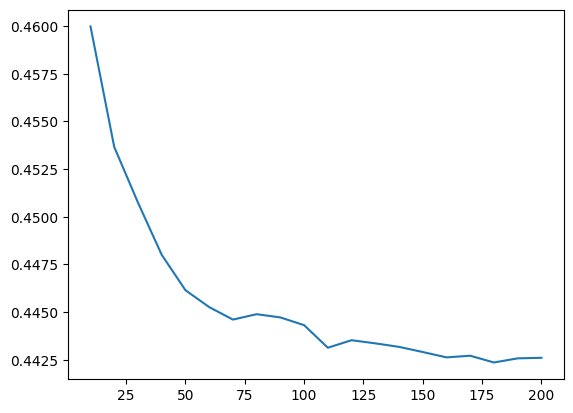

In [42]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'rmse'])
plt.plot(df_scores.n_estimators, df_scores.rmse)

### The `RMSE` stopped improving in the `n_stimators` `200`.

## Question 4

Let's select the best `max_depth`:

* Try different values of `max_depth`: `[10, 15, 20, 25]`
* For each of these values,
  * try different values of `n_estimators` from 10 till 200 (with step 10)
  * calculate the mean RMSE 
* Fix the random seed: `random_state=1`


What's the best `max_depth`, using the mean RMSE?

* 10
* 15
* 20
* 25

In [43]:
scores = []

for d in [10, 15, 20, 25]:
    for n in range(10, 201, 10):
        rf = RandomForestRegressor(
            n_estimators=n, 
            max_depth=d, 
            random_state=1,
            n_jobs=-1)
        
        rf.fit(X_train, y_train)
    
        y_pred = rf.predict(X_val)
        mse = mean_squared_error(y_val, y_pred)
        rmse = np.sqrt(mse)
        
        scores.append((d, n, rmse))

scores

[(10, 10, np.float64(0.45189498205368783)),
 (10, 20, np.float64(0.44871930280196803)),
 (10, 30, np.float64(0.44622482434107064)),
 (10, 40, np.float64(0.4438769469346297)),
 (10, 50, np.float64(0.4426823297364458)),
 (10, 60, np.float64(0.44234995527764454)),
 (10, 70, np.float64(0.4417931394907604)),
 (10, 80, np.float64(0.44195965762740047)),
 (10, 90, np.float64(0.44196681006003036)),
 (10, 100, np.float64(0.44177674543409867)),
 (10, 110, np.float64(0.4408469921594634)),
 (10, 120, np.float64(0.44096669954703027)),
 (10, 130, np.float64(0.4408325522436666)),
 (10, 140, np.float64(0.4405115320481308)),
 (10, 150, np.float64(0.440127581955975)),
 (10, 160, np.float64(0.43999675953472894)),
 (10, 170, np.float64(0.4401374684770232)),
 (10, 180, np.float64(0.4398370341427043)),
 (10, 190, np.float64(0.43998229381987186)),
 (10, 200, np.float64(0.43994243973670616)),
 (15, 10, np.float64(0.45715957363045534)),
 (15, 20, np.float64(0.4524623657720535)),
 (15, 30, np.float64(0.450477960

In [44]:
columns = ['max_depth', 'n_estimators', 'rmse']
df_scores = pd.DataFrame(scores, columns=columns)

In [45]:
df_scores

,max_depth,n_estimators,rmse
0,10,10,0.451895
1,10,20,0.448719
2,10,30,0.446225
3,10,40,0.443877
4,10,50,0.442682
...,...,...,...
75,25,160,0.442689
76,25,170,0.442767
77,25,180,0.442415
78,25,190,0.442618


In [46]:
means = []
for d in [10, 15, 20, 25]:
    mean = df_scores[df_scores.max_depth == d].rmse.mean()
    means.append((d, mean))

In [49]:
means

[(10, np.float64(0.44232130237115186)),
 (15, np.float64(0.44505999920137435)),
 (20, np.float64(0.4456441321803526)),
 (25, np.float64(0.44566060000292457))]

In [65]:
means_values = []
for x in means:
    means_values.append(x[1])

means_values

[np.float64(0.44232130237115186),
 np.float64(0.44505999920137435),
 np.float64(0.4456441321803526),
 np.float64(0.44566060000292457)]

In [67]:
data = {
    'max_depth': [10, 15, 20, 5],
    'mean': means_values
}

df_means = pd.DataFrame(data)

In [69]:
df_means

,max_depth,mean
0,10,0.442321
1,15,0.445060
2,20,0.445644
3,5,0.445661


### The best `max_depth` is `10`.

# Question 5

We can extract feature importance information from tree-based models. 

At each step of the decision tree learning algorithm, it finds the best split. 
When doing it, we can calculate "gain" - the reduction in impurity before and after the split. 
This gain is quite useful in understanding what are the important features for tree-based models.

In Scikit-Learn, tree-based models contain this information in the
[`feature_importances_`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html#sklearn.ensemble.RandomForestRegressor.feature_importances_)
field. 

For this homework question, we'll find the most important feature:

* Train the model with these parameters:
  * `n_estimators=10`,
  * `max_depth=20`,
  * `random_state=1`,
  * `n_jobs=-1` (optional)
* Get the feature importance information from this model


What's the most important feature (among these 4)? 

* `vehicle_weight`
*	`horsepower`
* `acceleration`
* `engine_displacement`	

In [70]:
rf = RandomForestRegressor(
            n_estimators=10, 
            max_depth=20, 
            random_state=1,
            n_jobs=-1)
        
rf.fit(X_train, y_train)
    
y_pred = rf.predict(X_val)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
rmse

np.float64(0.4591089597813361)

In [77]:
feature_names = dv.get_feature_names_out()
importances = rf.feature_importances_
feature_importance_map = dict(zip(feature_names, importances))
print(feature_importance_map)

{'acceleration': np.float64(0.011470716492980806), 'drivetrain=All-wheel drive': np.float64(0.0003818097503064216), 'drivetrain=Front-wheel drive': np.float64(0.0003118420847931972), 'engine_displacement': np.float64(0.003269323417164296), 'fuel_type=Diesel': np.float64(0.0003436934113118486), 'fuel_type=Gasoline': np.float64(0.0003366719883675566), 'horsepower': np.float64(0.016040214819390435), 'model_year': np.float64(0.003182298414589243), 'num_cylinders': np.float64(0.002358670936092339), 'num_doors': np.float64(0.0015911330645071602), 'origin=Asia': np.float64(0.0004761030460744537), 'origin=Europe': np.float64(0.0005203580827405701), 'origin=USA': np.float64(0.0005551519590829983), 'vehicle_weight': np.float64(0.9591620125325987)}


`acceleration`: `0.011470716492980806` \
`engine_displacement`: `0.003269323417164296` \
`horsepower`: `0.016040214819390435` \
`vehicle_weight`: `0.9591620125325987`

### The most important feature is `vehicle_weight`.

## Question 6

Now let's train an XGBoost model! For this question, we'll tune the `eta` parameter:

* Install XGBoost
* Create DMatrix for train and validation
* Create a watchlist
* Train a model with these parameters for 100 rounds:

```
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}
```

Now change `eta` from `0.3` to `0.1`.

Which eta leads to the best RMSE score on the validation dataset?

* 0.3
* 0.1
* Both give equal value

In [78]:
!pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [79]:
import xgboost as xgb

In [82]:
features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [99]:
%%capture output

xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=100, verbose_eval=5, evals=watchlist)

In [100]:
s = output.stdout

In [101]:
print(s)

[0]	train-rmse:1.81393	val-rmse:1.85444
[5]	train-rmse:0.51381	val-rmse:0.55664
[10]	train-rmse:0.37115	val-rmse:0.43896
[15]	train-rmse:0.34666	val-rmse:0.43362
[20]	train-rmse:0.33553	val-rmse:0.43376
[25]	train-rmse:0.32268	val-rmse:0.43683
[30]	train-rmse:0.31475	val-rmse:0.43752
[35]	train-rmse:0.30960	val-rmse:0.43784
[40]	train-rmse:0.30202	val-rmse:0.43968
[45]	train-rmse:0.29126	val-rmse:0.44024
[50]	train-rmse:0.28456	val-rmse:0.44140
[55]	train-rmse:0.27618	val-rmse:0.44225
[60]	train-rmse:0.26768	val-rmse:0.44290
[65]	train-rmse:0.26174	val-rmse:0.44352
[70]	train-rmse:0.25489	val-rmse:0.44531
[75]	train-rmse:0.24792	val-rmse:0.44628
[80]	train-rmse:0.24254	val-rmse:0.44689
[85]	train-rmse:0.23644	val-rmse:0.44749
[90]	train-rmse:0.23193	val-rmse:0.44839
[95]	train-rmse:0.22475	val-rmse:0.44904
[99]	train-rmse:0.21950	val-rmse:0.45018



In [102]:
%%capture output

xgb_params = {
    'eta': 0.1, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=100, verbose_eval=5, evals=watchlist)

In [103]:
s = output.stdout

In [104]:
print(s)

[0]	train-rmse:2.28944	val-rmse:2.34561
[5]	train-rmse:1.41247	val-rmse:1.44988
[10]	train-rmse:0.91008	val-rmse:0.94062
[15]	train-rmse:0.63402	val-rmse:0.66672
[20]	train-rmse:0.48983	val-rmse:0.53064
[25]	train-rmse:0.41881	val-rmse:0.46891
[30]	train-rmse:0.38342	val-rmse:0.44289
[35]	train-rmse:0.36435	val-rmse:0.43250
[40]	train-rmse:0.35343	val-rmse:0.42746
[45]	train-rmse:0.34621	val-rmse:0.42595
[50]	train-rmse:0.33998	val-rmse:0.42498
[55]	train-rmse:0.33480	val-rmse:0.42449
[60]	train-rmse:0.33054	val-rmse:0.42456
[65]	train-rmse:0.32602	val-rmse:0.42493
[70]	train-rmse:0.32202	val-rmse:0.42503
[75]	train-rmse:0.31895	val-rmse:0.42526
[80]	train-rmse:0.31667	val-rmse:0.42563
[85]	train-rmse:0.31440	val-rmse:0.42574
[90]	train-rmse:0.31059	val-rmse:0.42586
[95]	train-rmse:0.30625	val-rmse:0.42611
[99]	train-rmse:0.30419	val-rmse:0.42623



### The `eta` that resulted in the best RMSE on the validation dataset was `0.1`.